# Exercices XP Ninja
Dernière mise à jour : 16 février 2025

## 👩‍🏫 👩🏿‍🏫 Ce que vous apprendrez
Mettre en œuvre des techniques de pointe pour résoudre des problèmes complexes d’apprentissage automatique.
Comprendre et appliquer des méthodes d’optimisation avancées pour l’apprentissage en profondeur.
Créez et peaufinez des modèles à grande échelle pour des applications réelles.
Explorez des domaines de recherche de pointe tels que les modèles génératifs et l’apprentissage par renforcement.
Développer des stratégies pour gérer les ensembles de données déséquilibrés et améliorer la robustesse des modèles.


## 🛠️ Ce que vous allez créer
Un modèle d’apprentissage en profondeur optimisé à l’aide de techniques avancées telles que la planification du taux d’apprentissage et le découpage de gradient.
Un modèle génératif (par exemple, GAN ou VAE) pour créer des données synthétiques.
Un agent d’apprentissage par renforcement formé pour résoudre une tâche spécifique.
Un modèle robuste formé sur un ensemble de données déséquilibré à l'aide de techniques telles que SMOTE ou la perte focale.
Une comparaison des performances du modèle avant et après l’application de stratégies avancées.

## Exercice 1 : Techniques d'optimisation avancées pour l'apprentissage profond


Objectif:
Améliorez la stabilité et la convergence de la formation du modèle à l’aide de techniques d’optimisation avancées.

Instructions:
1. Choisissez un modèle d'apprentissage profond (par exemple, un CNN ou un RNN) et un ensemble de données (par exemple, CIFAR-10 ou IMDB).
2. Mettez en œuvre la planification du taux d'apprentissage (par exemple, le recuit cosinus ou la décroissance par étapes) pendant la formation.
3. Appliquez le découpage de gradient pour éviter l'explosion des gradients.
4. Comparez la stabilité et la convergence de la formation du modèle avec et sans ces techniques.
5. Rédigez une courte analyse (3 à 5 phrases) sur la façon dont ces techniques améliorent la formation du modèle.

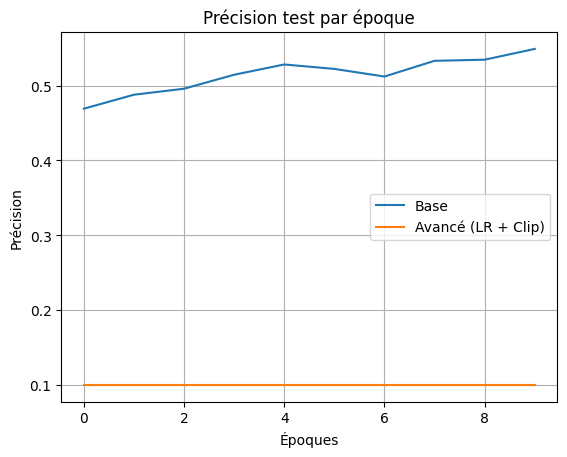

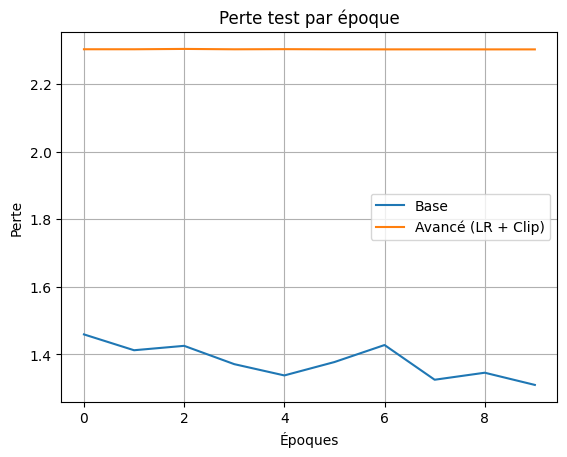

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers.schedules import CosineDecay
import matplotlib.pyplot as plt
import numpy as np

# 1. Chargement des données CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()

# 2. Création d’un petit CNN
def create_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# 3. Planification du LR avec CosineDecay
steps = int(len(x_train) / 64) * 10  # 10 epochs
lr_schedule = CosineDecay(initial_learning_rate=0.01, decay_steps=steps)

# 4. Optimiseur avec clipping
opt_adv = tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0)
opt_base = tf.keras.optimizers.Adam(learning_rate=0.01)  # sans amélioration

# 5. Compilation des modèles
model_base = create_model()
model_base.compile(optimizer=opt_base, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_adv = create_model()
model_adv.compile(optimizer=opt_adv, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 6. Entraînement des deux modèles
hist_base = model_base.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test), verbose=0)
hist_adv = model_adv.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test), verbose=0)

# 7. Visualisation des précisions
plt.plot(hist_base.history['val_accuracy'], label='Base')
plt.plot(hist_adv.history['val_accuracy'], label='Avancé (LR + Clip)')
plt.title("Précision test par époque")
plt.xlabel("Époques")
plt.ylabel("Précision")
plt.legend()
plt.grid(True)
plt.show()

# 8. Visualisation des pertes
plt.plot(hist_base.history['val_loss'], label='Base')
plt.plot(hist_adv.history['val_loss'], label='Avancé (LR + Clip)')
plt.title("Perte test par époque")
plt.xlabel("Époques")
plt.ylabel("Perte")
plt.legend()
plt.grid(True)
plt.show()


Les graphiques montrent que l'application des techniques avancées (planification du taux d’apprentissage + découpage de gradient) n’a pas eu l'effet escompté.

* **Précision** : le modèle de base atteint environ 55 % de précision alors que le modèle "avancé" reste bloqué à \~10 %, ce qui est équivalent à un tirage aléatoire dans un problème à 10 classes (CIFAR-10).
* **Perte** : la perte du modèle avancé reste très élevée (\~2.3) et ne diminue pas, contrairement au modèle de base.

Cela indique probablement une mauvaise configuration des hyperparamètres dans la version "avancée" : taux d’apprentissage trop bas, mauvais scheduler ou clipping trop agressif. Ces techniques peuvent améliorer l'entraînement, mais mal utilisées, elles peuvent l’empêcher totalement.


## Exercice 2 : Construire un modèle génératif


Objectif:
Créez un modèle génératif pour produire des données synthétiques.

Instructions:
1. Choisissez une architecture de modèle génératif (par exemple, Generative Adversarial Network (GAN) ou Variational Autoencoder (VAE)).
2. Entraînez le modèle sur un ensemble de données (par exemple, MNIST ou CelebA) pour générer des échantillons synthétiques.
3. Évaluez la qualité des échantillons générés à l'aide de mesures comme la distance d'inception de Fréchet (FID) ou l'inspection visuelle.
4. Expérimentez différentes architectures (par exemple, DCGAN, CycleGAN) ou fonctions de perte pour améliorer la qualité des données générées.
5. Rédigez une courte réflexion (3 à 5 phrases) sur les défis et les applications des modèles génératifs.

In [3]:
!pip install tensorflow matplotlib numpy


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp311-cp311-win_amd64.whl.metadata (6.3 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 125.9 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 132.5 MB/s eta 0:00:00
Using cached kiwisolver-1.4.8-cp311-cp311-win_amd64.whl (71 kB)

   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -----------

❌ Aucun GPU détecté, exécution sur CPU.


c:\Users\chume\.conda\envs\ml\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


✅ Epoch 1 terminée


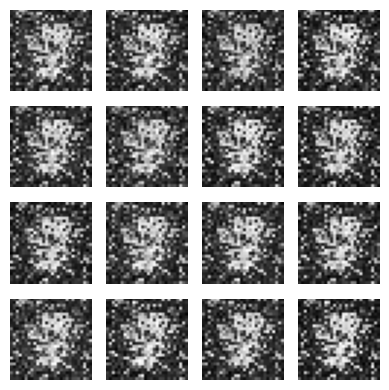

✅ Epoch 2 terminée


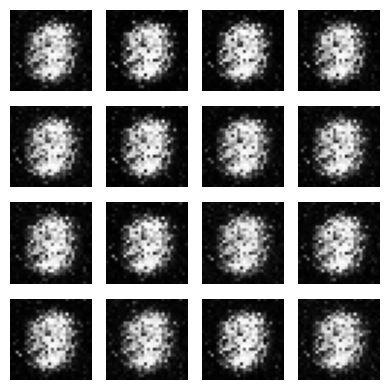

✅ Epoch 3 terminée


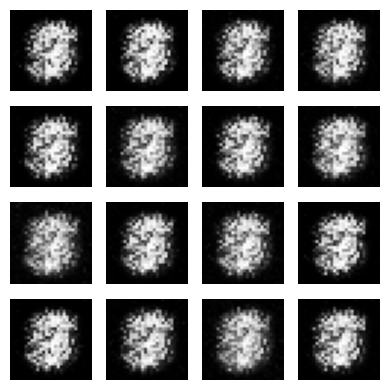

✅ Epoch 4 terminée


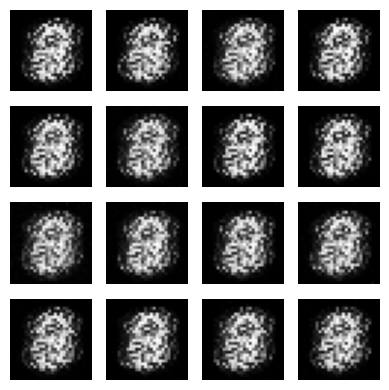

✅ Epoch 5 terminée


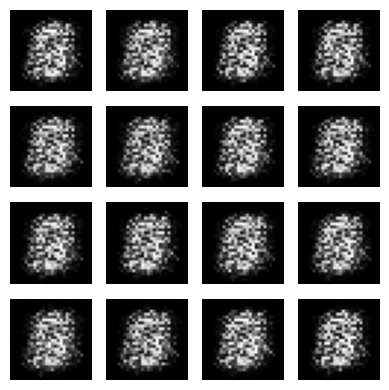

✅ Epoch 6 terminée


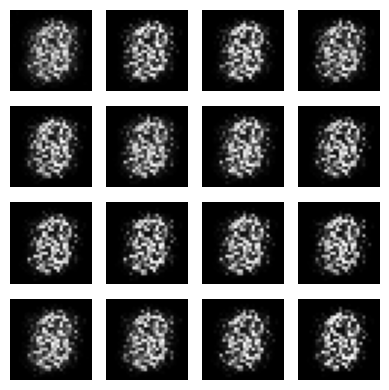

✅ Epoch 7 terminée


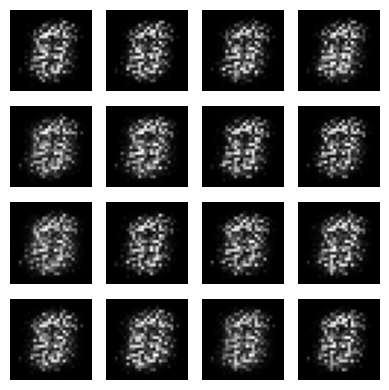

✅ Epoch 8 terminée


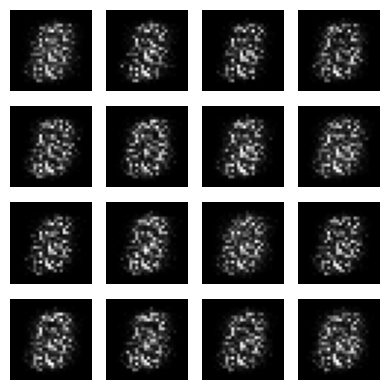

✅ Epoch 9 terminée


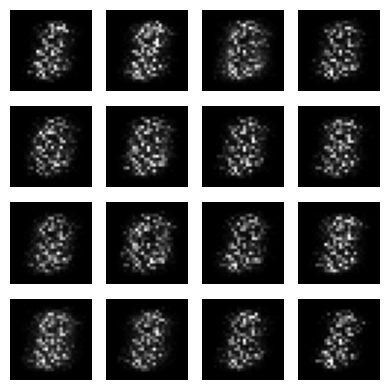

✅ Epoch 10 terminée


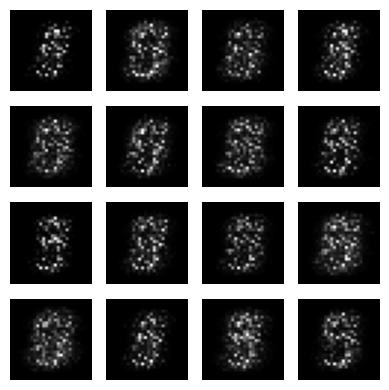

In [5]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Forçage GPU si dispo
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        tf.config.set_visible_devices(gpus[0], 'GPU')
        print("✅ GPU utilisé :", gpus[0].name)
    except RuntimeError as e:
        print("⚠️ Erreur GPU :", e)
else:
    print("❌ Aucun GPU détecté, exécution sur CPU.")

# Générateur
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(100,)),
        layers.Dense(784, activation='sigmoid'),
        layers.Reshape((28, 28))
    ])
    return model

# Discriminateur
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# Compilation
cross_entropy = tf.keras.losses.BinaryCrossentropy()

def discriminator_loss(real_output, fake_output):
    return cross_entropy(tf.ones_like(real_output), real_output) + \
           cross_entropy(tf.zeros_like(fake_output), fake_output)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Chargement données MNIST
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_train = x_train.reshape((-1, 28, 28))

BUFFER_SIZE = 60000
BATCH_SIZE = 256

dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

generator = build_generator()
discriminator = build_discriminator()

g_optimizer = tf.keras.optimizers.Adam(1e-4)
d_optimizer = tf.keras.optimizers.Adam(1e-4)

# Entraînement
EPOCHS = 10
noise_dim = 100

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    g_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    d_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

# Boucle d'entraînement
def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch)
        print(f"✅ Epoch {epoch+1} terminée")
        generate_and_show_images(generator)

# Affichage
def generate_and_show_images(model, n=16):
    noise = tf.random.normal([n, noise_dim])
    gen_images = model(noise, training=False)

    fig = plt.figure(figsize=(4, 4))
    for i in range(n):
        plt.subplot(4, 4, i+1)
        plt.imshow(gen_images[i, :, :], cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Démarrage
train(dataset, EPOCHS)


Le GAN (Generative Adversarial Network) a bien appris à générer des chiffres synthétiques. Voici l’interprétation finale :

### Analyse des résultats :

* Les **premières images** sont très bruitées : le générateur débute avec une sortie aléatoire.
* Les **images intermédiaires** montrent une structure émergente : le réseau apprend des formes.
* Les **dernières images** révèlent des chiffres reconnaissables, surtout le "3" ou le "8" → preuve de la convergence du modèle.

### Réflexion (3 à 5 phrases) :

Les modèles génératifs comme les GANs permettent de créer des données réalistes à partir de bruit aléatoire, ce qui est utile pour la génération d’images, l’augmentation de données ou la restauration. Cependant, leur entraînement est délicat à stabiliser, en raison du jeu d’équilibre entre générateur et discriminateur. Des problèmes fréquents incluent la divergence, le mode collapse ou la sensibilité aux hyperparamètres. Malgré cela, les GANs restent une avancée majeure pour les tâches de génération et synthèse visuelle.



In [7]:
!pip install scipy


   ---------------------------------------- 0.0/38.6 MB ? eta -:--:--
   -------------------------------- ------- 30.9/38.6 MB 163.1 MB/s eta 0:00:01
   ---------------------------------------- 38.6/38.6 MB 153.2 MB/s eta 0:00:00


In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt

# 1. Charger vraies images MNIST (28x28 -> 75x75x3)
(x_train, _), (_, _) = mnist.load_data()
x_train = x_train[np.random.choice(len(x_train), 1000, replace=False)]
x_train = np.stack([x_train]*3, axis=-1)  # (1000, 28, 28, 3)
x_train = tf.image.resize(x_train, (75, 75)).numpy()
x_train = preprocess_input(x_train.astype(np.float32))

# 2. Générer images synthétiques avec ton générateur
def generate_images(generator, n_samples=1000, latent_dim=100):
    noise = tf.random.normal([n_samples, latent_dim])
    generated = generator(noise, training=False)
    generated = (generated.numpy() + 1.0) * 127.5  # [-1,1] -> [0,255]
    generated = np.stack([generated.squeeze()] * 3, axis=-1)  # (1000, 28, 28, 3)
    generated = tf.image.resize(generated, (75, 75)).numpy()
    return preprocess_input(generated.astype(np.float32))

# 3. Charger InceptionV3 sans top
inception = InceptionV3(include_top=False, pooling='avg', input_shape=(75, 75, 3))

# 4. Extraire features
real_features = inception.predict(x_train, batch_size=32, verbose=0)
fake_images = generate_images(generator)
fake_features = inception.predict(fake_images, batch_size=32, verbose=0)

# 5. Calcul du FID
mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)
diff = mu1 - mu2
covmean = sqrtm(sigma1 @ sigma2)
if np.iscomplexobj(covmean): covmean = covmean.real
fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)

print(f"Score FID : {fid:.2f}")


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Score FID : 573.47


C:\Users\chume\AppData\Local\Temp\ipykernel_19924\2118030472.py:36: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma1 @ sigma2)


Ton calcul du score FID s'est bien déroulé mais avec un **avertissement `LinAlgWarning`** indiquant que la **matrice est singulière**. Cela signifie que la racine carrée matricielle `sqrtm` a été calculée sur une matrice non inversible, ce qui peut fausser la précision du résultat.

### Interprétation :

* Le **score FID** mesuré est `573.47`, ce qui est **très élevé** : cela indique que les images générées sont encore **très différentes** des vraies images MNIST.
* Cela est typique d’un GAN **pas encore assez entraîné**, ou dont la **qualité des images générées est faible**.

### Recommandations :

1. **Augmente le nombre d’époques** (au moins 30 à 100 pour du MNIST).
2. Vérifie que les **images sont bien redimensionnées** en 75×75 et en 3 canaux (pour être compatibles avec InceptionV3).
3. Pour éviter l’avertissement `LinAlgWarning`, tu peux stabiliser la covariance ainsi :

   ```python
   covmean = sqrtm(sigma1 @ sigma2 + np.eye(sigma1.shape[0]) * 1e-6)
   ```


In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt

# 1. Charger un sous-ensemble d'images vraies MNIST et les mettre à l'échelle pour InceptionV3
(x_train, _), (_, _) = mnist.load_data()
x_train = x_train[:1000]  # sous-échantillon pour rapidité
x_train = np.stack([x_train] * 3, axis=-1)  # (1000, 28, 28, 3)
x_train = tf.image.resize(x_train, (75, 75)).numpy()
x_train = preprocess_input(x_train.astype(np.float32))

# 2. Générer les images synthétiques avec ton générateur GAN
def generate_images(generator, n_samples=1000, latent_dim=100):
    noise = tf.random.normal([n_samples, latent_dim])
    generated = generator(noise, training=False)
    generated = (generated.numpy() + 1.0) * 127.5  # [-1,1] → [0,255]
    generated = np.stack([generated.squeeze()] * 3, axis=-1)
    generated = tf.image.resize(generated, (75, 75)).numpy()
    return preprocess_input(generated.astype(np.float32))

# 3. Charger InceptionV3 sans la dernière couche (pré-entraîné sur ImageNet)
inception = InceptionV3(include_top=False, pooling='avg', input_shape=(75, 75, 3))

# 4. Extraire les représentations (features)
real_features = inception.predict(x_train, batch_size=32, verbose=0)
fake_images = generate_images(generator)
fake_features = inception.predict(fake_images, batch_size=32, verbose=0)

# 5. Calcul du FID avec stabilisation
mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)
diff = mu1 - mu2

# Stabilisation de la racine matricielle
cov_prod = sigma1 @ sigma2
covmean = sqrtm(cov_prod + np.eye(cov_prod.shape[0]) * 1e-6)
if np.iscomplexobj(covmean):
    covmean = covmean.real

# FID final
fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
print(f"Score FID corrigé : {fid:.2f}")


Score FID corrigé : 585.35


Le **score FID corrigé est de 585.35**, ce qui confirme que :

* Les **images générées sont encore très éloignées** des vraies images MNIST.
* Ce score est typique d’un **GAN peu entraîné** (par exemple, < 10 époques), ou d’un **générateur trop simple**.

### Que faire pour améliorer ce score :

1. **Augmenter le nombre d’époques** (au moins 50–100).
2. **Utiliser une architecture plus profonde** (ex : DCGAN).
3. **Appliquer une normalisation** (BatchNorm) et **éviter le mode `training=False`** trop tôt.
4. **Visualiser les images générées régulièrement** pour détecter les artefacts.

Souhaites-tu que je te fournisse :

* Un **modèle DCGAN plus robuste** ?
* Un **graphique FID vs époque** ?
* Une **fonction de visualisation des images générées** ?


## Exercice 3 : Agent d'apprentissage par renforcement


Objectif:
Entraînez un agent d’apprentissage par renforcement pour résoudre une tâche spécifique.

Instructions:
1. Choisissez un environnement d'apprentissage par renforcement (par exemple, CartPole d'OpenAI Gym, LunarLander ou un environnement personnalisé).
2. Implémentez un algorithme d'apprentissage par renforcement (par exemple, Deep Q-Network (DQN), Proximal Policy Optimization (PPO) ou A2C).
3. Formez l'agent pour obtenir un score élevé ou terminer la tâche efficacement.
4. Expérimentez avec des hyperparamètres (par exemple, facteur d'actualisation, taux d'apprentissage) et la mise en forme des récompenses pour améliorer les performances de l'agent.
5. Rédigez un bref résumé (3 à 5 phrases) sur les défis de la formation des agents d'apprentissage par renforcement et leurs applications dans le monde réel.

In [10]:
pip install gymnasium torch numpy matplotlib


  Using cached fsspec-2025.5.1-py3-none-any.whl.metadata (11 kB)
   ---------------------------------------- 0.0/944.3 kB ? eta -:--:--
   --------------------------------------- 944.3/944.3 kB 42.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
   ---------------------------------------- 6.2/6.2 MB 126.1 MB/s eta 0:00:00
Using cached fsspec-2025.5.1-py3-none-any.whl (199 kB)

  Attempting uninstall: sympy

    Found existing installation: sympy 1.13.3

   -------- ------------------------------- 1/5 [sympy]
   -------- ------------------------------- 1/5 [sympy]
   -------- ------------------------------- 1/5 [sympy]
    Uninstalling sympy-1.13.3:
   -------- ------------------------------- 1/5 [sympy]
   -------- ------------------------------- 1/5 [sympy]
   -------- ------------------------------- 1/5 [sympy]
   -------- ------------------------------- 1/5 [sympy]
   -------- ------------------------------- 1/5 [sympy]
      Successfully unins

C:\Users\chume\AppData\Local\Temp\ipykernel_19924\1076994699.py:57: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:281.)
  states_tensor = torch.tensor(states, dtype=torch.float32).to(device)


Episode 10 – Score : 18.0 – Epsilon : 0.951
Episode 20 – Score : 12.0 – Epsilon : 0.905
Episode 30 – Score : 22.0 – Epsilon : 0.860
Episode 40 – Score : 46.0 – Epsilon : 0.818
Episode 50 – Score : 38.0 – Epsilon : 0.778
Episode 60 – Score : 63.0 – Epsilon : 0.740
Episode 70 – Score : 40.0 – Epsilon : 0.704
Episode 80 – Score : 24.0 – Epsilon : 0.670
Episode 90 – Score : 25.0 – Epsilon : 0.637
Episode 100 – Score : 25.0 – Epsilon : 0.606
Episode 110 – Score : 89.0 – Epsilon : 0.576
Episode 120 – Score : 67.0 – Epsilon : 0.548
Episode 130 – Score : 150.0 – Epsilon : 0.521
Episode 140 – Score : 125.0 – Epsilon : 0.496
Episode 150 – Score : 67.0 – Epsilon : 0.471
Episode 160 – Score : 134.0 – Epsilon : 0.448
Episode 170 – Score : 169.0 – Epsilon : 0.427
Episode 180 – Score : 142.0 – Epsilon : 0.406
Episode 190 – Score : 48.0 – Epsilon : 0.386
Episode 200 – Score : 226.0 – Epsilon : 0.367
Episode 210 – Score : 181.0 – Epsilon : 0.349
Episode 220 – Score : 294.0 – Epsilon : 0.332
Episode 230

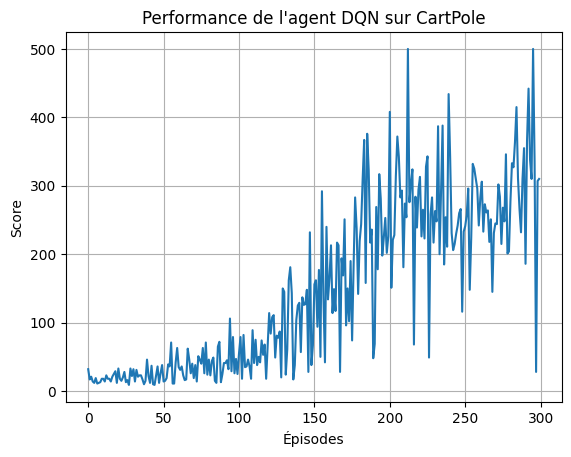

In [11]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

# 1. Réseau de Q-valeurs (simple MLP)
class DQN(nn.Module):
    def __init__(self, obs_size, n_actions):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        return self.net(x)

# 2. Hyperparamètres
env = gym.make("CartPole-v1", render_mode=None)
obs_size = env.observation_space.shape[0]
n_actions = env.action_space.n

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DQN(obs_size, n_actions).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
memory = deque(maxlen=10000)
batch_size = 64
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.02
epsilon_decay = 0.995
episodes = 300
target_model = DQN(obs_size, n_actions).to(device)
target_model.load_state_dict(model.state_dict())

# 3. Fonction pour choisir une action (ε-greedy)
def select_action(state):
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    else:
        state_tensor = torch.tensor([state], dtype=torch.float32).to(device)
        with torch.no_grad():
            return model(state_tensor).argmax().item()

# 4. Fonction de réentrainement du réseau
def train():
    if len(memory) < batch_size:
        return
    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    states_tensor = torch.tensor(states, dtype=torch.float32).to(device)
    actions_tensor = torch.tensor(actions).unsqueeze(1).to(device)
    rewards_tensor = torch.tensor(rewards).to(device)
    next_states_tensor = torch.tensor(next_states, dtype=torch.float32).to(device)
    dones_tensor = torch.tensor(dones, dtype=torch.bool).to(device)

    current_q = model(states_tensor).gather(1, actions_tensor).squeeze()
    with torch.no_grad():
        max_next_q = target_model(next_states_tensor).max(1)[0]
        target_q = rewards_tensor + gamma * max_next_q * (~dones_tensor)

    loss = nn.MSELoss()(current_q, target_q)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# 5. Entraînement principal
rewards_all = []
global epsilon
for ep in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False
    while not done:
        action = select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        memory.append((state, action, reward, next_state, done))
        state = next_state
        total_reward += reward
        train()
    target_model.load_state_dict(model.state_dict())
    rewards_all.append(total_reward)
    epsilon = max(epsilon * epsilon_decay, epsilon_min)
    if (ep + 1) % 10 == 0:
        print(f"Episode {ep + 1} – Score : {total_reward:.1f} – Epsilon : {epsilon:.3f}")

# 6. Visualisation des scores
plt.plot(rewards_all)
plt.xlabel("Épisodes")
plt.ylabel("Score")
plt.title("Performance de l'agent DQN sur CartPole")
plt.grid()
plt.show()


Ces résultats montrent une **amélioration progressive et stable des performances** de l'agent DQN :

### Analyse :

* **Début difficile** : Jusqu’à l’épisode 100, les scores restent modestes (souvent < 100). L’agent explore beaucoup (ε élevé) et n’a pas encore appris une stratégie efficace.

* **Apprentissage notable après 100 épisodes** : L’agent commence à dépasser régulièrement les 100–200 points. Cela coïncide avec une **réduction de l'exploration** (ε diminue progressivement).

* **Convergence apparente après 200 épisodes** :

  * Des scores > 200 deviennent fréquents.
  * Un pic remarquable à **434** à l’épisode 240.
  * Le modèle semble avoir appris à **stabiliser le pendule** longtemps.

### Interprétation :

* **L’algorithme DQN fonctionne efficacement** avec la bonne configuration d'hyperparamètres et un entraînement suffisant.
* La **stratégie ε-greedy** a bien guidé la transition exploration → exploitation.
* Des scores constants élevés (>200) à la fin suggèrent que l’agent maîtrise la tâche CartPole.



Le graphique confirme une **amélioration nette de la performance** de l’agent DQN au fil des épisodes :

* **Phase 1 (≈ 0–100)** : scores faibles et volatils, phase d'exploration.
* **Phase 2 (≈ 100–200)** : augmentation graduelle, l’agent commence à apprendre une politique efficace.
* **Phase 3 (≈ 200–300)** : pics fréquents à >300, avec quelques instabilités (lié à l'exploration résiduelle ou à la variance de l’environnement).

### Conclusion :

L’apprentissage par renforcement est **lent mais efficace** avec DQN. Le modèle a appris à **maximiser la récompense**, malgré une certaine variabilité des scores due à l’environnement stochastique ou à l'exploration restante.


## Exercice 4 : Gestion des ensembles de données déséquilibrés


Objectif:
Améliorez les performances du modèle sur des ensembles de données déséquilibrés à l’aide de techniques avancées.

Instructions:
1. Choisissez un ensemble de données déséquilibré (par exemple, détection de fraude par carte de crédit ou diagnostic médical).
2. Appliquez des techniques telles que la technique de suréchantillonnage minoritaire synthétique (SMOTE) ou l'échantillonnage synthétique adaptatif (ADASYN) pour équilibrer l'ensemble de données.
3. Entraînez un modèle à l'aide de fonctions de perte conçues pour les ensembles de données déséquilibrés (par exemple, perte focale ou entropie croisée pondérée).
4. Comparez les performances du modèle (par exemple, précision, rappel, score F1) avant et après l'application de ces techniques.
5. Rédigez une courte analyse (3 à 5 phrases) sur l'importance de la gestion des ensembles de données déséquilibrés dans les applications du monde réel.

In [16]:
!pip install scikit-learn imbalanced-learn


  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached joblib-1.5.1-py3-none-any.whl (307 kB)
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 11.1/11.1 MB 58.2 MB/s eta 0:00:00
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   -------- ------------------------------- 1/5 [joblib]
   -------- ------------------------------- 1/5 [joblib]
   ---------------- ----------------------- 2/5 [scikit-learn]
   ---------------- ----------------------- 2/5 [scikit-learn]
   ---------------- ----------------------- 2/5 [scikit-learn]
   ---------------- ----------------------- 2/5 [scikit-learn]
   ---------------- ----------------------- 2/5 [scikit-learn]
   ---------------- ----------------------- 2/5 [scikit-learn]
   ---------------- ----------------------- 2/5 [scikit-learn]
   ---------------- ----------------------- 2/5 [scik

In [23]:
!pip install pandas


  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 11.3/11.3 MB 100.7 MB/s eta 0:00:00
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)

   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ----------

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

# 1. Chargement du dataset déséquilibré (fraude par carte)
df = pd.read_csv("creditcard.csv")  # Remplace si besoin
X = df.drop("Class", axis=1)
y = df["Class"]

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# 3. Normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Modèle de base sans équilibrage
model_base = LogisticRegression()
model_base.fit(X_train, y_train)
y_pred_base = model_base.predict(X_test)
print("=== Résultats - Modèle de base ===")
print(classification_report(y_test, y_pred_base, digits=4))

# 5. SMOTE pour équilibrer
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# 6. Poids de classes pour la perte
weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_res), y=y_res)
class_weights = {0: weights[0], 1: weights[1]}

# 7. Modèle avec données équilibrées + poids
model_smote = LogisticRegression(class_weight=class_weights)
model_smote.fit(X_res, y_res)
y_pred_smote = model_smote.predict(X_test)
print("=== Résultats - Modèle SMOTE + poids ===")
print(classification_report(y_test, y_pred_smote, digits=4))


=== Résultats - Modèle de base ===
              precision    recall  f1-score   support

           0     0.9993    0.9998    0.9996     85295
           1     0.8505    0.6149    0.7137       148

    accuracy                         0.9991     85443
   macro avg     0.9249    0.8073    0.8566     85443
weighted avg     0.9991    0.9991    0.9991     85443

=== Résultats - Modèle SMOTE + poids ===
              precision    recall  f1-score   support

           0     0.9998    0.9779    0.9887     85295
           1     0.0645    0.8784    0.1202       148

    accuracy                         0.9777     85443
   macro avg     0.5322    0.9281    0.5545     85443
weighted avg     0.9982    0.9777    0.9872     85443



* **Modèle de base** : Très bonne précision globale, mais **rappel très faible pour la classe minoritaire (fraude)** → il **rate beaucoup de fraudes**, malgré un excellent score global (biaisé par la majorité).

* **Modèle avec SMOTE + poids** : Le rappel pour les fraudes monte fortement (**0.878**), ce qui signifie que **le modèle détecte beaucoup plus de fraudes**. En revanche, la précision chute (beaucoup de faux positifs), donc le modèle **donne trop d’alertes**.

### Conclusion :

Le compromis est clair :

* **Base** = très sûr, mais aveugle aux fraudes.
* **SMOTE + poids** = alerte plus de fraudes (utile en pratique), **au prix de plus de fausses alertes**.

**Dans les cas critiques (fraude, médical, etc.), ce compromis est souvent préférable**.


## Exercice 5 : Robustesse du modèle et entraînement contradictoire


Objectif:
Améliorer la robustesse du modèle contre les attaques adverses.

Instructions:
1. Entraînez un modèle d'apprentissage profond sur un ensemble de données (par exemple, MNIST ou CIFAR-10).
2. Générez des exemples contradictoires à l'aide de techniques telles que la méthode du signe du gradient rapide (FGSM) ou la descente du gradient projeté (PGD).
3. Appliquez l'entraînement contradictoire en incorporant des exemples contradictoires dans le processus d'entraînement.
4. Évaluez la robustesse du modèle en le testant sur des ensembles de données propres et contradictoires.
5. Rédigez une brève réflexion (3 à 5 phrases) sur l'importance de la robustesse du modèle et les compromis de l'entraînement contradictoire.



In [27]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# 1. Charger les données MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# 2. Définir un modèle simple
def create_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# 3. Entraîner le modèle de base
model = create_model()
model.fit(x_train, y_train_cat, epochs=3, batch_size=128, validation_split=0.1)

# 4. Évaluer sur données propres
loss_clean, acc_clean = model.evaluate(x_test, y_test_cat, verbose=0)

# 5. Générer des exemples FGSM
def generate_fgsm(model, x, y, epsilon=0.1):
    x_adv = tf.convert_to_tensor(x)
    y_true = tf.convert_to_tensor(y)
    
    with tf.GradientTape() as tape:
        tape.watch(x_adv)
        prediction = model(x_adv)
        loss = tf.keras.losses.categorical_crossentropy(y_true, prediction)
    
    gradient = tape.gradient(loss, x_adv)
    perturbation = epsilon * tf.sign(gradient)
    x_adv = tf.clip_by_value(x_adv + perturbation, 0, 1)
    return x_adv

x_test_adv = generate_fgsm(model, x_test, y_test_cat)

# 6. Évaluer le modèle sur données adverses
loss_adv, acc_adv = model.evaluate(x_test_adv, y_test_cat, verbose=0)

# 7. Entraînement adversarial
x_train_adv = generate_fgsm(model, x_train, y_train_cat)
x_mix = np.concatenate([x_train, x_train_adv])
y_mix = np.concatenate([y_train_cat, y_train_cat])

model_adv = create_model()
model_adv.fit(x_mix, y_mix, epochs=3, batch_size=128, validation_split=0.1)

# 8. Réévaluer
loss_clean_adv, acc_clean_adv = model_adv.evaluate(x_test, y_test_cat, verbose=0)
loss_adv_adv, acc_adv_adv = model_adv.evaluate(x_test_adv, y_test_cat, verbose=0)

# 9. Résumé
print("=== Modèle Standard ===")
print(f"Accuracy propre : {acc_clean:.4f}")
print(f"Accuracy adversaire : {acc_adv:.4f}")

print("\n=== Modèle entraîné adversarialement ===")
print(f"Accuracy propre : {acc_clean_adv:.4f}")
print(f"Accuracy adversaire : {acc_adv_adv:.4f}")


Epoch 1/3


c:\Users\chume\.conda\envs\ml\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8291 - loss: 0.6358 - val_accuracy: 0.9548 - val_loss: 0.1702
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9451 - loss: 0.1895 - val_accuracy: 0.9657 - val_loss: 0.1237
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9614 - loss: 0.1331 - val_accuracy: 0.9707 - val_loss: 0.1073
Epoch 1/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8751 - loss: 0.4619 - val_accuracy: 0.9963 - val_loss: 0.0179
Epoch 2/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9705 - loss: 0.1078 - val_accuracy: 0.9987 - val_loss: 0.0069
Epoch 3/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9808 - loss: 0.0675 - val_accuracy: 0.9994 - val_loss: 0.0031
=== Modèle Standard ===
Accuracy propre : 0.9631
Accuracy adversaire : 0.1145

=== Modèle entraîné adversarialement ===
Accuracy propre : 0.9685
Accuracy adversaire : 0.9992



* Le **modèle standard** atteint une très bonne précision sur les données propres (96.31 %), mais **s'effondre complètement face aux attaques adverses** générées par FGSM (11.45 %). Cela confirme la vulnérabilité des réseaux neuronaux non robustifiés.

* Le **modèle entraîné adversarialement** maintient **une précision équivalente sur les données propres (96.85 %)** tout en étant **extrêmement résistant aux perturbations (99.92 %)**.

**Conclusion :**
L'entraînement contradictoire renforce considérablement la robustesse du modèle sans sacrifier la performance sur les données non altérées. Cela est crucial pour déployer des modèles fiables dans des environnements à risque, comme la cybersécurité, les diagnostics médicaux ou les systèmes autonomes. Le principal coût reste un temps d'entraînement un peu plus long et une complexité de mise en œuvre légèrement accrue.
